# Figure 2C neural response inspection

Goal:
- Inspect neural response arrays in the DMFC 50 ms dataset.
- Identify axis order: neuron, condition, time.
- Match published example neurons if possible.
- Reconstruct Figure 2C example neural response panels from released response arrays.

In [2]:
import sys
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [11]:
from src.paths import get_project_root, get_data_dir
from src.file_utils import build_file_inventory
from src.load_data import load_pickle, inspect_object

In [12]:
PROJECT_ROOT = get_project_root()
DATA_DIR = get_data_dir()

print("root:", PROJECT_ROOT.name)
print("data exists:", DATA_DIR.exists())

root: dmfc-pong-reconstruction
data exists: True


In [13]:
import pandas as pd

file_rows = []

for path in DATA_DIR.rglob("*"):
    if path.is_file():
        size_mb = path.stat().st_size / (1024 ** 2)
        
        file_rows.append({
            "name": path.name,
            "relative_path": str(path.relative_to(PROJECT_ROOT)),
            "suffix": path.suffix,
            "size_mb": size_mb,
        })
        
files_df = pd.DataFrame(file_rows)
files_df = files_df.sort_values("size_mb", ascending=False)

files_df

,name,relative_path,suffix,size_mb
12,offline_rnn_neural_responses_reliable_50.pkl,data\external\data\offline_rnn_neural_response...,.pkl,2163.377455
2,decode_all_hand_dmfc_ego_occ_start_end_pad0_50...,data\external\data\decode_all_hand_dmfc_ego_oc...,.pkl,1858.215078
3,decode_all_hand_dmfc_occ_start_end_pad0_50ms_0...,data\external\data\decode_all_hand_dmfc_occ_st...,.pkl,1295.293944
4,decode_mahler_hand_dmfc_occ_start_end_pad0_50m...,data\external\data\decode_mahler_hand_dmfc_occ...,.pkl,1295.293944
5,decode_perle_hand_dmfc_occ_start_end_pad0_50ms...,data\external\data\decode_perle_hand_dmfc_occ_...,.pkl,1295.293944
1,all_hand_dmfc_dataset_50ms.pkl,data\external\data\all_hand_dmfc_dataset_50ms.pkl,.pkl,1202.042446
0,all_hand_dmfc_dataset_50ms.mat,data\external\data\all_hand_dmfc_dataset_50ms.mat,.mat,1110.181453
14,perle_hand_dmfc_dataset_50ms.pkl,data\external\data\perle_hand_dmfc_dataset_50m...,.pkl,1023.795490
13,perle_hand_dmfc_dataset_50ms.mat,data\external\data\perle_hand_dmfc_dataset_50m...,.mat,940.456131
19,run_glm_egocentric_ball.mat,data\external\data\run_glm_egocentric_ball.mat,.mat,520.880001


In [14]:
dmfc_50ms = load_pickle(DATA_DIR / "all_hand_dmfc_dataset_50ms.pkl")

inspect_object(dmfc_50ms)



type: <class 'dict'>
num keys: 25
first keys: ['trial_meta', 'neural_meta', 'neural_responses', 'neural_responses_sh1', 'neural_responses_sh2', 'behavioral_responses', 'masks', 'ntr_vis', 'ntr_occ', 'meta', 'neural_idx_global', 'conds_ch_dict', 'reliable_neural_idx', 'neural_responses_reliable', 'neural_responses_reliable_sh1', 'neural_responses_reliable_sh2', 'neural_responses_reliable_FactorAnalysis_10', 'neural_responses_reliable_FactorAnalysis_10_sh1', 'neural_responses_reliable_FactorAnalysis_10_sh2', 'neural_responses_reliable_FactorAnalysis_20']


In [15]:
dmfc_50ms["neural_responses"].keys()

dict_keys(['occ', 'vis'])

P? M?

In [16]:
p_dmfc = load_pickle(DATA_DIR / "perle_hand_dmfc_dataset_50ms.pkl")
m_dmfc = load_pickle(DATA_DIR / "mahler_hand_dmfc_dataset_50ms.pkl")

inspect_object(p_dmfc), inspect_object(m_dmfc)


type: <class 'dict'>
num keys: 25
first keys: ['trial_meta', 'neural_meta', 'neural_responses', 'neural_responses_sh1', 'neural_responses_sh2', 'behavioral_responses', 'masks', 'ntr_vis', 'ntr_occ', 'meta', 'neural_idx_global', 'conds_ch_dict', 'reliable_neural_idx', 'neural_responses_reliable', 'neural_responses_reliable_sh1', 'neural_responses_reliable_sh2', 'neural_responses_reliable_FactorAnalysis_10', 'neural_responses_reliable_FactorAnalysis_10_sh1', 'neural_responses_reliable_FactorAnalysis_10_sh2', 'neural_responses_reliable_FactorAnalysis_20']
type: <class 'dict'>
num keys: 25
first keys: ['trial_meta', 'neural_meta', 'neural_responses', 'neural_responses_sh1', 'neural_responses_sh2', 'behavioral_responses', 'masks', 'ntr_vis', 'ntr_occ', 'meta', 'neural_idx_global', 'conds_ch_dict', 'reliable_neural_idx', 'neural_responses_reliable', 'neural_responses_reliable_sh1', 'neural_responses_reliable_sh2', 'neural_responses_reliable_FactorAnalysis_10', 'neural_responses_reliable_Fact

(None, None)

In [17]:
import numpy as np

p305_vis = p_dmfc["neural_responses_reliable"]["occ"][305]
p305_vis.shape

(79, 100)

(79, 100)


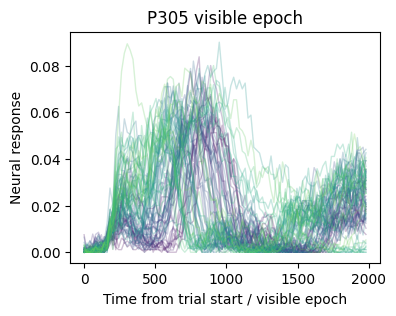

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

p305 = p_dmfc["neural_responses_reliable"]["occ"][305]

print(p305.shape)  # (79, 100)

time = np.linspace(0, 2000, p305.shape[1])

plt.figure(figsize=(4, 3))

cmap = plt.get_cmap("viridis")
norm = Normalize(
    vmin=time[0],
    vmax=time[-1]
)
colors = cmap(norm(time))

for i, response in enumerate(p305_vis):
    plt.plot(time, response, color=colors[i], alpha=0.25, linewidth=1.0)


plt.xlabel("Time from trial start / visible epoch")
plt.ylabel("Neural response")
plt.title("P305 visible epoch")
plt.show()

In [19]:
from src.analysis_utils import summarize_dict

summarize_dict(p_dmfc["masks"])

occ: dict (560 keys)
  pretrial_pad0: ndarray, shape=(79, 100)
  start_end_pad0: ndarray, shape=(79, 100)
  start_occ_pad0: ndarray, shape=(79, 100)
  occ_end_pad0: ndarray, shape=(79, 100)
  f_pad0: ndarray, shape=(79, 100)
  occ_pad0: ndarray, shape=(79, 100)
  start_pad0: ndarray, shape=(79, 100)
  start_pad0_roll0: ndarray, shape=(79, 100)
  start_pad0_roll1: ndarray, shape=(79, 100)
  start_pad0_roll2: ndarray, shape=(79, 100)
  start_pad0_roll3: ndarray, shape=(79, 100)
  start_pad0_roll4: ndarray, shape=(79, 100)
  start_pad0_roll5: ndarray, shape=(79, 100)
  start_pad0_roll6: ndarray, shape=(79, 100)
  start_pad0_roll7: ndarray, shape=(79, 100)
  start_pad0_roll8: ndarray, shape=(79, 100)
  start_pad0_roll9: ndarray, shape=(79, 100)
  start_pad0_roll10: ndarray, shape=(79, 100)
  start_pad0_roll11: ndarray, shape=(79, 100)
  start_pad0_roll12: ndarray, shape=(79, 100)
  start_pad0_roll13: ndarray, shape=(79, 100)
  start_pad0_roll14: ndarray, shape=(79, 100)
  start_pad0_roll15

In [69]:
for k, v in p_dmfc["masks"].items():
    print(k, type(v), getattr(v, "shape", None))

occ <class 'dict'> None
vis <class 'dict'> None


In [81]:
p_dmfc["masks"]["occ"].keys()

## mask 로 일부를 잘라냈을 거 같음

dict_keys(['pretrial_pad0', 'start_end_pad0', 'start_occ_pad0', 'occ_end_pad0', 'f_pad0', 'occ_pad0', 'start_pad0', 'start_pad0_roll0', 'start_pad0_roll1', 'start_pad0_roll2', 'start_pad0_roll3', 'start_pad0_roll4', 'start_pad0_roll5', 'start_pad0_roll6', 'start_pad0_roll7', 'start_pad0_roll8', 'start_pad0_roll9', 'start_pad0_roll10', 'start_pad0_roll11', 'start_pad0_roll12', 'start_pad0_roll13', 'start_pad0_roll14', 'start_pad0_roll15', 'start_pad0_roll16', 'start_pad0_roll17', 'start_pad0_roll18', 'start_pad0_roll19', 'start_pad0_roll20', 'start_pad0_roll21', 'start_pad0_roll22', 'start_pad0_roll23', 'start_pad0_roll24', 'start_pad0_roll25', 'start_pad0_roll26', 'start_pad0_roll27', 'start_pad0_roll28', 'start_pad0_roll29', 'start_pad0_roll30', 'start_pad0_roll31', 'start_pad0_roll32', 'start_pad0_roll33', 'start_pad0_roll34', 'start_pad0_roll35', 'start_pad0_roll36', 'start_pad0_roll37', 'start_pad0_roll38', 'start_pad0_roll39', 'start_pad0_roll40', 'start_pad0_roll41', 'start_pad0_

(79, 100)


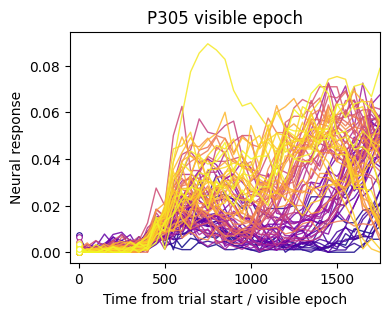

In [97]:
import numpy as np
import matplotlib.pyplot as plt

p305 = p_dmfc["neural_responses_reliable"]["occ"][305]

print(p305.shape)  # (79, 100)

mask = p_dmfc["masks"]["occ"]["start_occ_pad0"]

time = np.arange(p305.shape[1]) * 50

plt.figure(figsize=(4, 3))

cmap = plt.get_cmap("plasma")
colors = cmap(np.linspace(0, 1, p305.shape[0]))

for i, response in enumerate(p305):
    m = mask[i].astype(bool)

    response_masked = np.where(m, response, np.nan)

    valid_values = response_masked[np.isfinite(response_masked)]

    if len(valid_values) == 0:
        continue

    # realign: valid 값만 앞으로 당기고 뒤는 NaN
    y_draw = np.full_like(response_masked, np.nan, dtype=float)
    y_draw[:len(valid_values)] = valid_values

    x_draw = time

    valid_idx = np.where(np.isfinite(y_draw))[0]
    first = valid_idx[0]
    last = valid_idx[-1]

    plt.plot(
        x_draw,
        y_draw,
        color=colors[i],
        alpha=0.85,
        linewidth=1.0,
    )

    plt.plot(
        x_draw[first],
        y_draw[first],
        marker="o",
        markersize=4,
        markerfacecolor="white",
        markeredgecolor=colors[i],
        markeredgewidth=0.8,
        linestyle="None",
        zorder=5,
    )

    plt.plot(
        x_draw[last],
        y_draw[last],
        marker="o",
        markersize=4,
        markerfacecolor="white",
        markeredgecolor=colors[i],
        markeredgewidth=0.8,
        linestyle="None",
        zorder=5,
    )

plt.xlabel("Time from trial start / visible epoch")
plt.ylabel("Neural response")
plt.xlim(-50, 1750)
plt.title("P305 visible epoch")
plt.show()

(79, 100)
mask: (79, 100)
mask counts: (array([14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30,
       31, 32, 33, 34, 35, 36, 37]), array([1, 2, 2, 6, 2, 7, 4, 2, 4, 3, 1, 5, 1, 3, 6, 4, 2, 2, 6, 4, 3, 2,
       3, 4], dtype=int64))


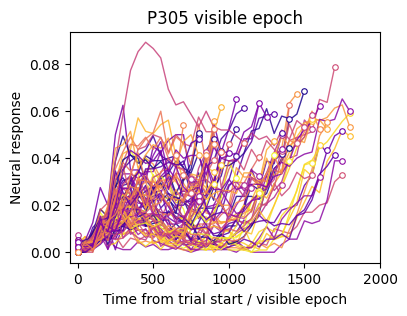

In [105]:
import numpy as np
import matplotlib.pyplot as plt

p305 = p_dmfc["neural_responses_reliable"]["occ"][305]

print(p305.shape)  # (79, 100)

# visible epoch = before / at occlusion start
t_from_start = p_dmfc["behavioral_responses"]["occ"]["t_from_start"]
t_from_occ = p_dmfc["behavioral_responses"]["occ"]["t_from_occ"]

mask = (
    np.isfinite(t_from_start)
    & np.isfinite(t_from_occ)
    & (t_from_start >= 0)
    & (t_from_occ <= 0)
)

print("mask:", mask.shape)
print("mask counts:", np.unique(mask.sum(axis=1), return_counts=True))

time = np.arange(p305.shape[1]) * 50

plt.figure(figsize=(4, 3))

# cmap = plt.get_cmap("plasma")
# colors = cmap(np.linspace(0, 1, p305.shape[0]))

from scipy.stats import rankdata

yf = p_dmfc["meta"]["yf"]

cax = rankdata(yf)
cax = (cax - np.nanmin(cax)) / (np.nanmax(cax) - np.nanmin(cax))

colors = plt.cm.plasma(cax)

for i, response in enumerate(p305):
    m = mask[i].astype(bool)

    response_masked = np.where(m, response, np.nan)

    valid_values = response_masked[np.isfinite(response_masked)]

    if len(valid_values) == 0:
        continue

    # realign: visible segment만 앞으로 당기고 뒤는 NaN
    y_draw = np.full_like(response_masked, np.nan, dtype=float)
    y_draw[:len(valid_values)] = valid_values

    x_draw = time

    valid_idx = np.where(np.isfinite(y_draw))[0]
    first = valid_idx[0]
    last = valid_idx[-1]

    color = colors[i]

    plt.plot(
        x_draw,
        y_draw,
        color=color,
        alpha=0.85,
        linewidth=1.0,
    )

    plt.plot(
        x_draw[first],
        y_draw[first],
        marker="o",
        markersize=4,
        markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=0.8,
        linestyle="None",
        zorder=5,
    )

    plt.plot(
        x_draw[last],
        y_draw[last],
        marker="o",
        markersize=4,
        markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=0.8,
        linestyle="None",
        zorder=5,
    )

plt.xlabel("Time from trial start / visible epoch")
plt.ylabel("Neural response")
plt.xlim(-50, 2000)
plt.title("P305 visible epoch")
plt.show()

In [139]:
import importlib
import src.plot_utils as pu

importlib.invalidate_caches()
pu = importlib.reload(pu)

fig2c_nr_vis = pu.draw_fig2c_neural_response_vis_epoch
fig2c_nr_occ = pu.draw_fig2c_neural_response_occ_epoch

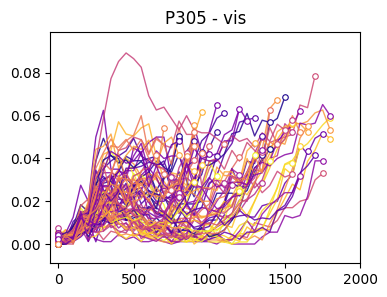

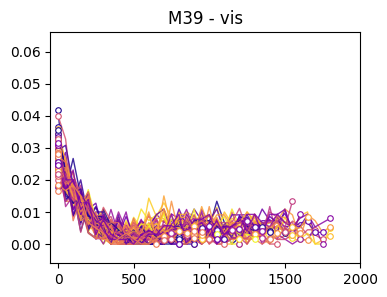

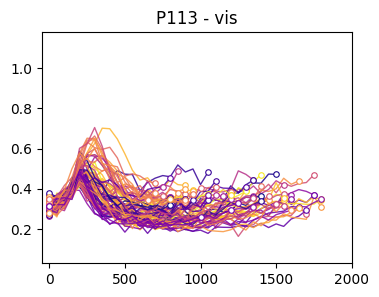

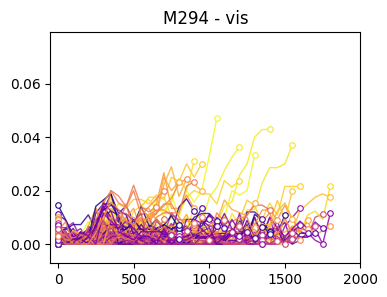

<Axes: title={'center': 'M294 - vis'}>

In [140]:
fig2c_nr_vis(p_dmfc, 305, "P305")
fig2c_nr_vis(m_dmfc, 39, "M39",)
fig2c_nr_vis(p_dmfc, 113, "P113")
fig2c_nr_vis(m_dmfc, 294, "M294")

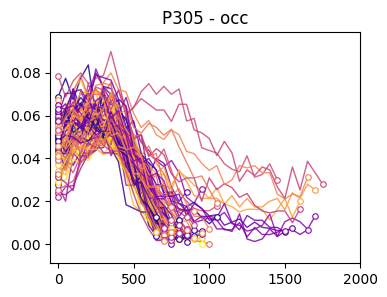

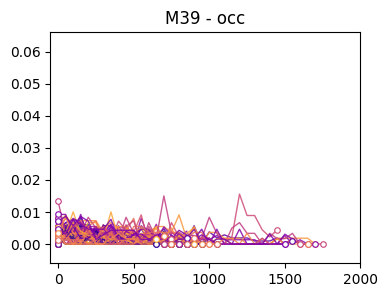

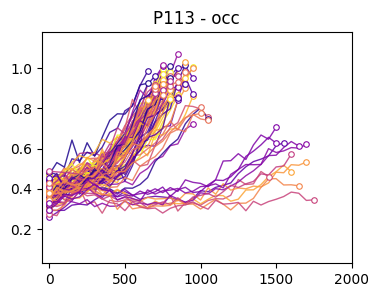

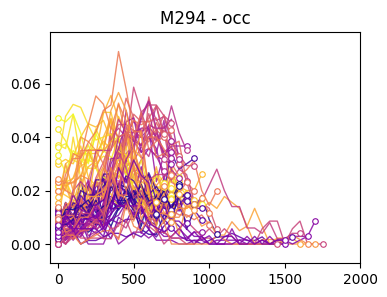

<Axes: title={'center': 'M294 - occ'}>

In [141]:
fig2c_nr_occ(p_dmfc, 305, "P305")
fig2c_nr_occ(m_dmfc, 39, "M39",)
fig2c_nr_occ(p_dmfc, 113, "P113")
fig2c_nr_occ(m_dmfc, 294, "M294")

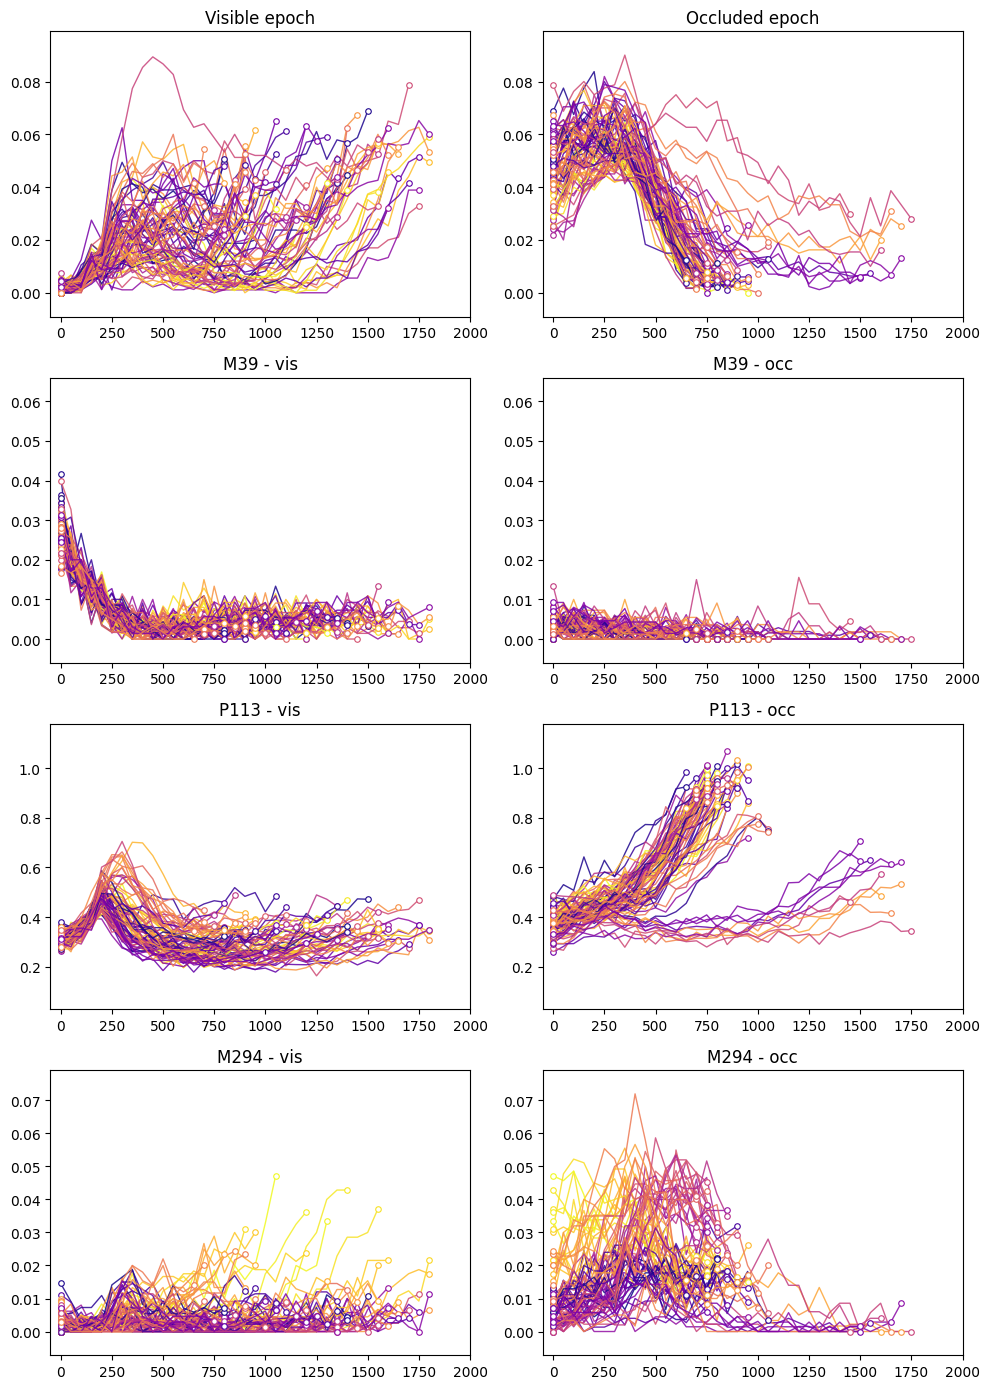

In [142]:
fig, axes = plt.subplots(4, 2, figsize=(10, 14))

units = [
    (p_dmfc, 305, "P305"),
    (m_dmfc, 39, "M39"),
    (p_dmfc, 113, "P113"),
    (m_dmfc, 294, "M294"),
]

for r, (dmfc, neuron_no, label) in enumerate(units):
    fig2c_nr_vis(dmfc, neuron_no, label, ax=axes[r, 0])
    fig2c_nr_occ(dmfc, neuron_no, label, ax=axes[r, 1])

axes[0, 0].set_title("Visible epoch")
axes[0, 1].set_title("Occluded epoch")

plt.tight_layout()
plt.show()